## APhys Group Meeting (9/6/2026)

In [27]:
# imports
import xarray as xr
import numpy as np
import scipy
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
lake = 'Zug'

bathy = xr.open_dataset(f'Q:/Messdaten/Aphys_Hypothesis_data/{lake}/bathymetry.nc')

c:\Users\herremha\AppData\Local\anaconda3\envs\ewg\Lib\site-packages\xarray\backends\plugins.py:110: RuntimeWarning: Engine 'gini' loading failed:
DLL load failed while importing _context: The specified module could not be found.
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
<frozen importlib._bootstrap>:488: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject


In [137]:
#x = 2679917
x = 2679750
y1 = 1218000
y2 = 1219000

transect_w = bathy.sel(xsc=x, ysc=slice(y1, y2)).depth

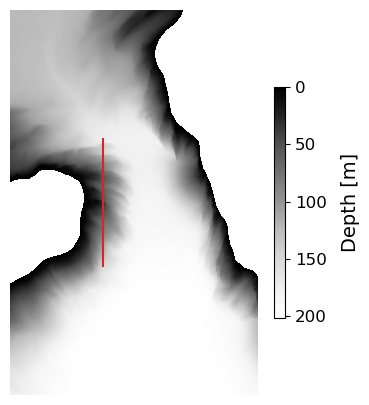

In [138]:
bathy_sel = bathy.sel(xsc=slice(2679000, 2681000), ysc=slice(1217000, 1220000))

fig, ax = plt.subplots(figsize=(4, 5))

im = ax.pcolormesh(bathy_sel['xsc'], bathy_sel['ysc'], bathy_sel['depth'], cmap='Greys_r', vmin=0, rasterized=True)
cbar = fig.colorbar(im, shrink=0.6, ax=ax)
cbar.set_label('Depth [m]', fontsize=14, labelpad=10)
cbar.ax.tick_params(labelsize=12)
cbar.ax.invert_yaxis()

ax.vlines(x, ymin=y1, ymax=y2, color='tab:red')

ax.set_xticks([])
ax.set_yticks([])
ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

plt.show()

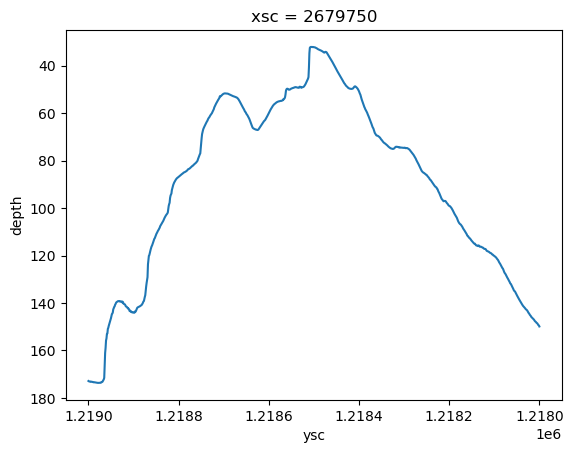

In [139]:
fig, ax = plt.subplots()

transect_w.plot(ax=ax)

ax.invert_xaxis()
ax.invert_yaxis()
plt.show()

In [140]:
freqs, pows = scipy.signal.welch(transect_w, fs=1, nperseg=len(transect_w))
freqs = freqs[1:]
k = 2 * np.pi * freqs
pows = pows[1:]

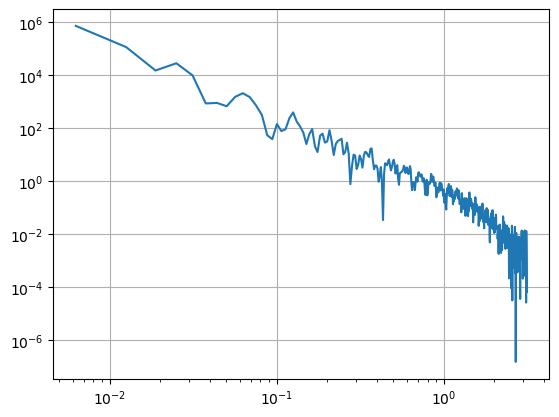

In [141]:
fig, ax = plt.subplots()

sns.lineplot(x=k, y=pows, ax=ax)

ax.set_xscale('log')
ax.set_yscale('log')

ax.grid(True)

plt.show()

In [142]:
# Create a mask to isolate wavenumbers between 0.1 and 0.4
mask = (k >= 0.05) & (k <= 0.1)

# Find the index of the highest power within that specific bump
peak_idx = np.argmax(pows[mask])

# Extract the exact wavenumber and calculate its wavelength
dominant_k = k[mask][peak_idx]
dominant_wavelength = (2 * np.pi) / dominant_k

print(f"Exact Peak Wavenumber: {dominant_k:.4f} rad/m")
print(f"Characteristic Wavelength: {dominant_wavelength:.1f} meters")

Exact Peak Wavenumber: 0.0628 rad/m
Characteristic Wavelength: 100.1 meters
